# Advanced ML Workflow: Acquisition, Value, and Incremental Growth

A second, self-contained synthetic case study. A subscription business must rank leads, forecast revenue, allocate limited offers, and detect changes after launch. We compare **six classifier families, four regressors, three forecasters, and two uplift learners**. Every result is computed from seeded simulations; none represents a real employer or customer.

## Decision map
| Scenario | Decision | Evaluation design | Main evidence |
|---|---|---|---|
| Conversion propensity | Review the top 15% of leads | Fit / select / calibrate / final test | AP, Brier, precision and recall at capacity |
| Customer value | Estimate 90-day revenue | Separate interval calibration and test | MAE, RMSE, 90% interval coverage |
| Weekly acquisition | Staff next week's volume | Expanding-window, one-step backtests | MAE and WAPE against seasonal naive |
| Incremental offers | Contact the most persuadable 20% | Randomized treatment, held-out policy evaluation | IPW value, oracle simulation value, regret |
| Post-launch shifts | Investigate or roll back | Frozen model, newly simulated labeled cohorts | Input drift versus outcome degradation |

Run all cells in order with the repository requirements installed. Outputs are written beneath `advanced_case_study_artifacts/`. Small datasets and single-process estimators keep this runnable on a laptop. This is an educational batch-scoring prototype, not a production service.

In [1]:
from pathlib import Path
import json, platform, time, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, joblib
from IPython.display import display
from scipy.special import expit
from scipy.stats import ks_2samp
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge, ElasticNet
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
    HistGradientBoostingClassifier, RandomForestRegressor, HistGradientBoostingRegressor)
from sklearn.svm import SVC
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
    log_loss, mean_absolute_error, mean_squared_error)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit

SEED=2026
rng=np.random.default_rng(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format='{:,.3f}'.format
OUT=Path('advanced_case_study_artifacts'); OUT.mkdir(exist_ok=True)
versions={'python':platform.python_version(),'numpy':np.__version__,
          'pandas':pd.__version__,'scikit-learn':sklearn.__version__}
display(pd.Series(versions,name='Executed environment').to_frame())

,Executed environment
python,3.12.14
numpy,2.5.2
pandas,2.3.3
scikit-learn,1.9.0


## 1. Generate a nonlinear customer funnel and enforce the data contract

Each row is a distinct lead observed at acquisition. Sessions and intent summarize only pre-scoring activity. Conversion and revenue occur during the following 90 days. The data-generating probability, future revenue, and outcome are deliberately excluded from model inputs. Interactions, channel effects, right-skewed spend, and missing intent make a linear classifier an imperfect challenger.

These independent cohorts support a random split under an exchangeability assumption. Real repeated customers need group splits; production acquisition cohorts need time splits with a 90-day label-maturity embargo. The later forecasting experiment uses chronological validation explicitly.

,dtype,missing_pct
sessions,int64,0.000
intent,float64,4.233
spend,float64,0.000
company_size,int64,0.000
channel,object,0.000
region,object,0.000


,partition,n,conversion_rate,purpose
0,fit,3000,0.147,Fit models
1,selection,1000,0.160,Choose model family
2,calibration,1000,0.162,Calibrate probabilities / intervals
3,test,1000,0.163,Frozen final evaluation


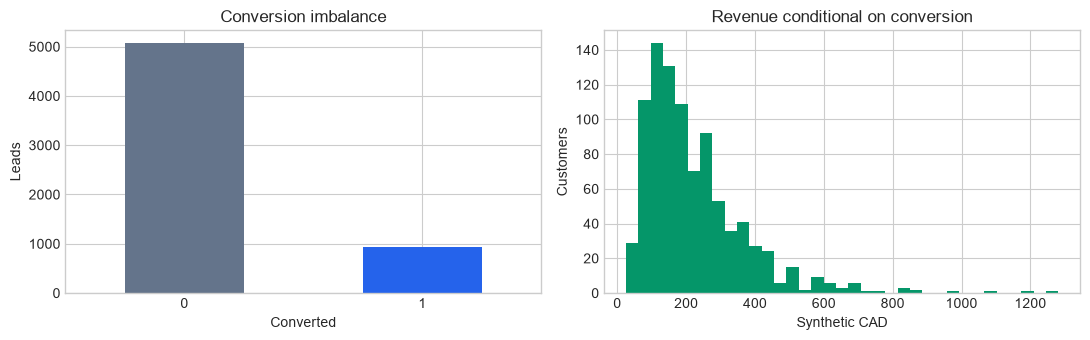

In [2]:
NUM=['sessions','intent','spend','company_size']
CAT=['channel','region']; FEATURES=NUM+CAT
def simulate(n,seed,shift='stable'):
    r=np.random.default_rng(seed)
    x=pd.DataFrame({'sessions':r.poisson(4 if shift!='traffic' else 7,n),
        'intent':r.beta(2,3,n),'spend':r.lognormal(3.5,.7,n),
        'company_size':r.integers(1,100,n),
        'channel':r.choice(['Search','Social','Referral'],n,p=[.45,.4,.15]),
        'region':r.choice(['East','West','Central'],n)})
    z=(-3.5+.2*x.sessions+2*x.intent+.7*(x.channel=='Referral')
       +1.3*((x.sessions>5)&(x.intent>.5))-.004*x.spend)
    if shift=='concept': z=z-1.8*(x.channel=='Search')+1.2*(x.channel=='Social')
    p=expit(z); y=r.binomial(1,p)
    revenue=y*np.exp(4.6+.009*x.company_size+.4*x.intent+r.normal(0,.55,n))
    x.loc[r.random(n)<(.35 if shift=='missing' else .04),'intent']=np.nan
    return x,np.asarray(y),np.asarray(revenue),np.asarray(p)
X,y,revenue,oracle_p=simulate(6000,SEED)
ids=rng.permutation(len(X))
fit,select,cal,test=np.split(ids,[3000,4000,5000])
assert set(FEATURES)==set(X.columns)
assert all(not(set(a)&set(b)) for i,a in enumerate([fit,select,cal,test]) for b in [fit,select,cal,test][i+1:])
assert X.sessions.ge(0).all() and set(np.unique(y))=={0,1}
contract=pd.DataFrame({'dtype':X.dtypes.astype(str),'missing_pct':100*X.isna().mean()})
split_table=pd.DataFrame([{'partition':name,'n':len(idx),'conversion_rate':y[idx].mean(),
    'purpose':purpose} for name,idx,purpose in [
    ('fit',fit,'Fit models'),('selection',select,'Choose model family'),
    ('calibration',cal,'Calibrate probabilities / intervals'),('test',test,'Frozen final evaluation')]])
display(contract); display(split_table)
fig,ax=plt.subplots(1,2,figsize=(11,3.5))
pd.Series(y).value_counts().sort_index().plot.bar(ax=ax[0],color=['#64748b','#2563eb'],rot=0)
ax[0].set(title='Conversion imbalance',xlabel='Converted',ylabel='Leads')
ax[1].hist(revenue[revenue>0],bins=35,color='#059669'); ax[1].set(title='Revenue conditional on conversion',xlabel='Synthetic CAD',ylabel='Customers')
plt.tight_layout(); plt.show()
def prep():
    return ColumnTransformer([
        ('num',make_pipeline(SimpleImputer(strategy='median',add_indicator=True),StandardScaler()),NUM),
        ('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),CAT)])

## 2. Compare six classifier families on the same selection cohort

All learned preprocessing is inside a freshly constructed pipeline. Hyperparameters are fixed, modest budgets rather than an expensive tuning contest. Selection uses average precision (AP); it is not PR trapezoidal area. Timing is descriptive and hardware-dependent. The test cohort is not consulted when choosing a winner. A larger production search would use nested or repeated validation and report selection uncertainty.

,model,selection_AP,selection_ROC_AUC,selection_Brier,fit_and_score_seconds
1,Logistic,0.378,0.715,0.121,0.027
3,Extra trees,0.342,0.706,0.125,0.190
2,Random forest,0.342,0.696,0.123,0.287
4,Histogram boosting,0.328,0.678,0.126,0.145
5,RBF SVM,0.297,0.617,0.128,0.792
0,Prior,0.160,0.500,0.135,0.073


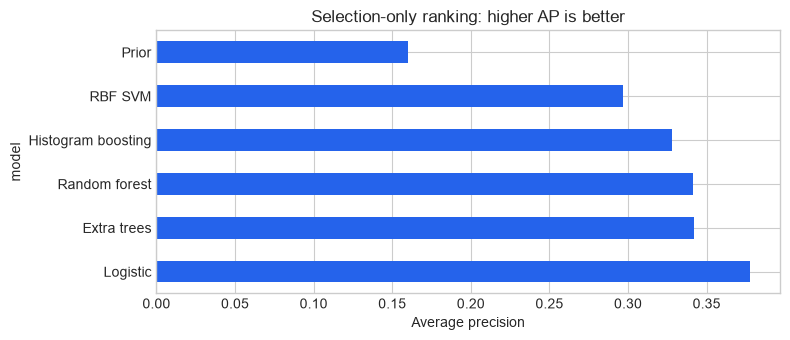

Frozen champion: Logistic


In [3]:
candidates={
 'Prior':DummyClassifier(strategy='prior'),
 'Logistic':LogisticRegression(C=1,max_iter=1000),
 'Random forest':RandomForestClassifier(n_estimators=100,min_samples_leaf=12,max_depth=9,random_state=SEED,n_jobs=1),
 'Extra trees':ExtraTreesClassifier(n_estimators=100,min_samples_leaf=12,random_state=SEED,n_jobs=1),
 'Histogram boosting':HistGradientBoostingClassifier(max_iter=110,max_leaf_nodes=12,l2_regularization=3,random_state=SEED),
 'RBF SVM':SVC(C=1,random_state=SEED)}
models={}; rows=[]
for name,est in candidates.items():
    start=time.perf_counter(); m=make_pipeline(prep(),est)
    if name=='RBF SVM': m=CalibratedClassifierCV(m,cv=3,ensemble=False)
    m.fit(X.iloc[fit],y[fit]); models[name]=m
    p=m.predict_proba(X.iloc[select])[:,1]
    rows.append({'model':name,'selection_AP':average_precision_score(y[select],p),
       'selection_ROC_AUC':roc_auc_score(y[select],p),'selection_Brier':brier_score_loss(y[select],p),
       'fit_and_score_seconds':time.perf_counter()-start})
leaderboard=pd.DataFrame(rows).sort_values('selection_AP',ascending=False)
winner=leaderboard.iloc[0]['model']; champion=models[winner]
display(leaderboard)
leaderboard.plot.barh(x='model',y='selection_AP',legend=False,figsize=(8,3.5),color='#2563eb')
plt.title('Selection-only ranking: higher AP is better'); plt.xlabel('Average precision'); plt.tight_layout(); plt.show()
print('Frozen champion:',winner)

## 3. Calibrate without refitting the underlying model; evaluate at capacity

A sigmoid calibrator is fitted only on the separate calibration cohort. The classifier is then frozen: refitting it after selecting a calibration mapping would change the score distribution. Calibration is pre-specified, not selected by test performance. We report raw and calibrated test probabilities even if calibration hurts.

The operating policy reviews exactly the top 15% of a batch. This is a capacity policy, not an assumed 0.5 threshold. Stable ordering makes tied scores deterministic. Precision-at-capacity is prediction quality, **not incremental marketing ROI**.

,model,AP,ROC_AUC,Brier,log_loss,precision_at_15pct,recall_at_15pct
0,Raw champion,0.426,0.702,0.120,0.400,0.460,0.423
1,Calibrated champion,0.426,0.702,0.119,0.399,0.460,0.423


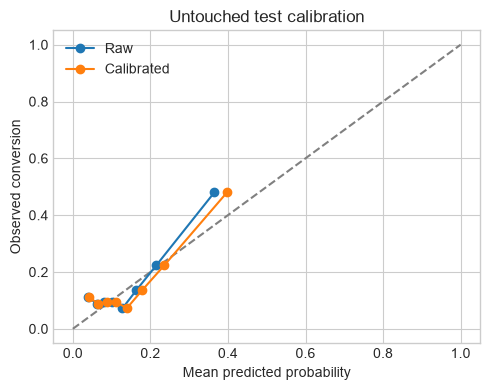

,metric,estimate,bootstrap_2.5pct,bootstrap_97.5pct
0,Test AP,0.426,0.355,0.507


In [4]:
def logit_scores(p):
    p=np.clip(p,1e-6,1-1e-6); return np.log(p/(1-p)).reshape(-1,1)
calibrator=LogisticRegression(C=1e3,max_iter=1000).fit(
    logit_scores(champion.predict_proba(X.iloc[cal])[:,1]),y[cal])
def score(frame):
    return calibrator.predict_proba(logit_scores(champion.predict_proba(frame)[:,1]))[:,1]
raw=champion.predict_proba(X.iloc[test])[:,1]; prob=score(X.iloc[test])
def metric_row(label,actual,p):
    k=max(1,int(.15*len(p))); chosen=np.argsort(-p,kind='stable')[:k]
    return {'model':label,'AP':average_precision_score(actual,p),'ROC_AUC':roc_auc_score(actual,p),
       'Brier':brier_score_loss(actual,p),'log_loss':log_loss(actual,p),
       'precision_at_15pct':actual[chosen].mean(),'recall_at_15pct':actual[chosen].sum()/max(1,actual.sum())}
final_metrics=pd.DataFrame([metric_row('Raw champion',y[test],raw),metric_row('Calibrated champion',y[test],prob)])
display(final_metrics)
fig,ax=plt.subplots(figsize=(5,4)); ax.plot([0,1],[0,1],'--',color='gray')
for label,p in [('Raw',raw),('Calibrated',prob)]:
    observed,predicted=calibration_curve(y[test],p,n_bins=8,strategy='quantile')
    ax.plot(predicted,observed,'o-',label=label)
ax.set(title='Untouched test calibration',xlabel='Mean predicted probability',ylabel='Observed conversion'); ax.legend()
plt.tight_layout(); plt.show()
# Bootstrap quantifies test sampling uncertainty conditional on the frozen training workflow.
boot_rng=np.random.default_rng(SEED+1)
boot=[]
for _ in range(300):
    b=boot_rng.integers(0,len(test),len(test))
    boot.append(average_precision_score(y[test][b],prob[b]))
display(pd.DataFrame({'metric':['Test AP'],'estimate':[average_precision_score(y[test],prob)],
    'bootstrap_2.5pct':[np.quantile(boot,.025)],'bootstrap_97.5pct':[np.quantile(boot,.975)]}))

## 4. Diagnose slices and predictive explanations

Slice counts and event counts are shown alongside metrics; small slices are noisy. These operational regions are not a complete protected-group fairness audit. Permutation importance measures predictive reliance on held-out data, not causal influence. Correlated predictors can dilute importance. These diagnostics do not trigger retuning on the test set.

,region,n,events,AP,Brier,mean_score,observed_rate
0,Central,330,52,0.359,0.121,0.141,0.158
1,East,329,55,0.470,0.118,0.172,0.167
2,West,341,56,0.456,0.118,0.158,0.164


,feature,AP_drop,std
0,sessions,0.182,0.002
1,intent,0.134,0.008
4,channel,0.076,0.009
5,region,0.006,0.006
3,company_size,0.001,0.000
2,spend,-0.000,0.000


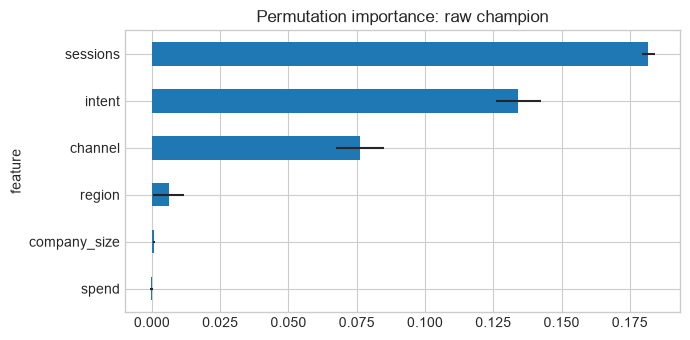

In [5]:
slices=[]
for region in sorted(X.region.unique()):
    mask=X.iloc[test].region.to_numpy()==region
    slices.append({'region':region,'n':int(mask.sum()),'events':int(y[test][mask].sum()),
        'AP':average_precision_score(y[test][mask],prob[mask]),
        'Brier':brier_score_loss(y[test][mask],prob[mask]),
        'mean_score':prob[mask].mean(),'observed_rate':y[test][mask].mean()})
display(pd.DataFrame(slices))
imp=permutation_importance(champion,X.iloc[test],y[test],scoring='average_precision',n_repeats=4,random_state=SEED,n_jobs=1)
importance=pd.DataFrame({'feature':FEATURES,'AP_drop':imp.importances_mean,'std':imp.importances_std})
display(importance.sort_values('AP_drop',ascending=False))
importance.sort_values('AP_drop').plot.barh(x='feature',y='AP_drop',xerr='std',legend=False,figsize=(7,3.5))
plt.title('Permutation importance: raw champion'); plt.tight_layout(); plt.show()

## 5. Predict customer value and quantify uncertainty

Revenue is zero-inflated and heteroscedastic. Four regressors use the same fit and selection partitions, optimizing MAE. A split-conformal interval uses absolute residuals on calibration data with the finite-sample rank correction. Under exchangeability this targets **marginal** 90% coverage, not per-customer or subgroup coverage. Nonnegative clipping is valid because revenue cannot be negative. Wide intervals are an honest consequence of this noisy target; they do not imply the model is useless for ranking.

,model,selection_MAE
2,Random forest,52.304
3,Histogram boosting,52.521
1,Elastic net,52.813
0,Mean,56.580


,model,test_MAE,test_RMSE,coverage_90pct,mean_width
0,Random forest,54.338,104.619,0.915,163.957


,region,n,coverage
0,Central,330,0.909
1,East,329,0.918
2,West,341,0.918


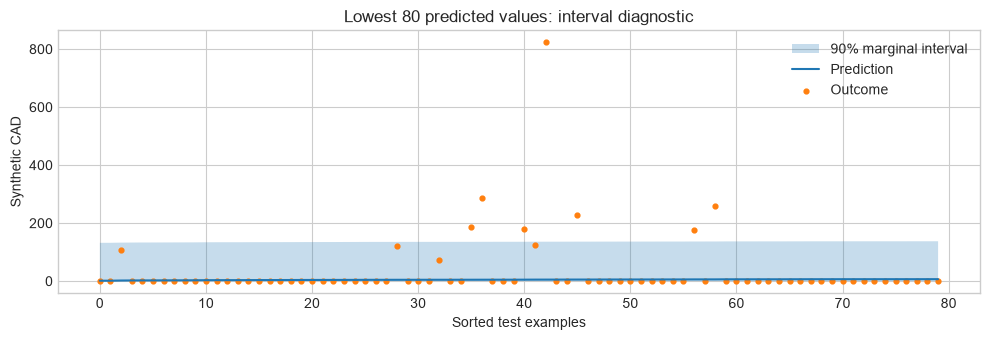

In [6]:
regressors={'Mean':DummyRegressor(), 'Elastic net':ElasticNet(alpha=.15,l1_ratio=.3,max_iter=4000),
 'Random forest':RandomForestRegressor(n_estimators=100,min_samples_leaf=15,random_state=SEED,n_jobs=1),
 'Histogram boosting':HistGradientBoostingRegressor(max_iter=100,max_leaf_nodes=10,l2_regularization=5,random_state=SEED)}
reg_models={}; reg_rows=[]
for name,est in regressors.items():
    m=make_pipeline(prep(),est).fit(X.iloc[fit],revenue[fit]); reg_models[name]=m
    pred=np.maximum(0,m.predict(X.iloc[select]))
    reg_rows.append({'model':name,'selection_MAE':mean_absolute_error(revenue[select],pred)})
reg_table=pd.DataFrame(reg_rows).sort_values('selection_MAE'); display(reg_table)
reg_name=reg_table.iloc[0]['model']; reg=reg_models[reg_name]
residual=np.abs(revenue[cal]-np.maximum(0,reg.predict(X.iloc[cal])))
alpha=.1; rank=min(len(cal),int(np.ceil((len(cal)+1)*(1-alpha))))
radius=np.sort(residual)[rank-1]
value_pred=np.maximum(0,reg.predict(X.iloc[test])); lo=np.maximum(0,value_pred-radius); hi=value_pred+radius
covered=(revenue[test]>=lo)&(revenue[test]<=hi)
display(pd.DataFrame([{'model':reg_name,'test_MAE':mean_absolute_error(revenue[test],value_pred),
 'test_RMSE':np.sqrt(mean_squared_error(revenue[test],value_pred)),
 'coverage_90pct':covered.mean(),'mean_width':np.mean(hi-lo)}]))
display(pd.DataFrame([{'region':g,'n':int((X.iloc[test].region==g).sum()),
 'coverage':covered[X.iloc[test].region.to_numpy()==g].mean()} for g in sorted(X.region.unique())]))
order=np.argsort(value_pred)[:80]
plt.figure(figsize=(10,3.5)); plt.fill_between(np.arange(len(order)),lo[order],hi[order],alpha=.25,label='90% marginal interval')
plt.plot(value_pred[order],label='Prediction'); plt.scatter(np.arange(len(order)),revenue[test][order],s=12,label='Outcome')
plt.title('Lowest 80 predicted values: interval diagnostic'); plt.xlabel('Sorted test examples'); plt.ylabel('Synthetic CAD'); plt.legend(); plt.tight_layout(); plt.show()

## 6. Forecast acquisition with expanding-window backtests

We forecast one week ahead using lagged realized demand, known calendar seasonality, and a trend. Lag features use only prior weeks. Three expanding folds compare seasonal naive, ridge regression, and gradient boosting. Test weeks in each fold are evaluated as **rolling one-step** forecasts: prior test outcomes become observable before the next forecast. This is not a multi-week forecast made at one origin. No future observed demand is used as a feature.

,fold,model,train_weeks,MAE,WAPE
0,1,Seasonal naive,78,38.365,0.123
1,1,Ridge,78,15.012,0.048
2,1,Boosted lags,78,20.568,0.066
3,2,Seasonal naive,104,34.768,0.087
4,2,Ridge,104,14.677,0.037
5,2,Boosted lags,104,28.006,0.070
6,3,Seasonal naive,130,39.461,0.113
7,3,Ridge,130,17.109,0.049
8,3,Boosted lags,130,21.816,0.062


,MAE,WAPE
model,,
Boosted lags,23.464,0.066
Ridge,15.600,0.045
Seasonal naive,37.531,0.108


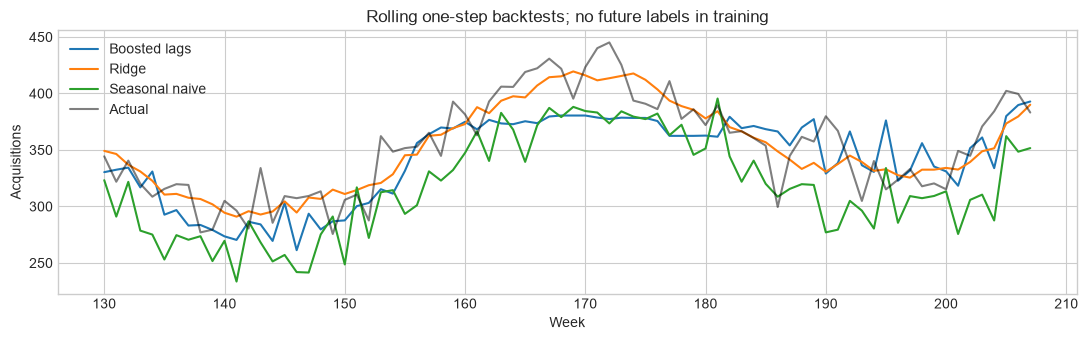

In [7]:
t=np.arange(208); frng=np.random.default_rng(SEED+2)
demand=250+.7*t+55*np.sin(2*np.pi*t/52)+frng.normal(0,18,len(t))
series=pd.DataFrame({'demand':demand,'trend':t,'sin':np.sin(2*np.pi*t/52),'cos':np.cos(2*np.pi*t/52)})
for lag in [1,2,4,52]: series[f'lag_{lag}']=series.demand.shift(lag)
series['rolling_4']=series.demand.shift(1).rolling(4).mean()
series=series.dropna(); forecast_features=[c for c in series if c!='demand']
tscv=TimeSeriesSplit(n_splits=3,test_size=26); forecast_rows=[]; forecast_predictions=[]
for fold,(tr,te) in enumerate(tscv.split(series),1):
    a,b=series.iloc[tr],series.iloc[te]
    predictions={'Seasonal naive':b.lag_52.to_numpy()}
    for name,est in [('Ridge',make_pipeline(StandardScaler(),Ridge(alpha=10))),
                     ('Boosted lags',HistGradientBoostingRegressor(max_iter=80,max_leaf_nodes=6,min_samples_leaf=10,random_state=SEED))]:
        est.fit(a[forecast_features],a.demand); predictions[name]=est.predict(b[forecast_features])
    for name,p in predictions.items():
        forecast_rows.append({'fold':fold,'model':name,'train_weeks':len(a),'MAE':mean_absolute_error(b.demand,p),
             'WAPE':np.abs(b.demand.to_numpy()-p).sum()/np.abs(b.demand).sum()})
        forecast_predictions.append(pd.DataFrame({'week':b.index,'actual':b.demand.to_numpy(),'pred':p,'model':name}))
forecast_table=pd.DataFrame(forecast_rows); display(forecast_table)
display(forecast_table.groupby('model')[['MAE','WAPE']].mean())
fp=pd.concat(forecast_predictions)
plt.figure(figsize=(11,3.5))
for name,g in fp.groupby('model'): plt.plot(g.week,g.pred,label=name)
actual=fp.drop_duplicates('week'); plt.plot(actual.week,actual.actual,color='black',alpha=.5,label='Actual')
plt.title('Rolling one-step backtests; no future labels in training'); plt.ylabel('Acquisitions'); plt.xlabel('Week'); plt.legend(); plt.tight_layout(); plt.show()

## 7. Estimate incremental response with a randomized offer experiment

Conversion propensity is not treatment effect. We generate a separate randomized experiment with known assignment probability 0.5, positive and negative heterogeneous offer effects, and one observed potential outcome per customer. An S-learner models outcome using features plus treatment; a T-learner fits separate treatment/control response models.

Train learners on 6,000 rows and evaluate a pre-specified top-20%-positive-net-benefit policy on 3,000 untouched rows. The policy earns CAD 100 per incremental conversion and costs CAD 3 per contact. The inverse-propensity-weighted (IPW) estimate is noisy but identifiable under randomization, consistency, overlap, and no interference. Oracle effects are used **only for simulation diagnostics**, never as training labels. Bootstrap intervals below are conditional on the fitted models and fixed cohort allocation.

,policy,contact_rate,IPW_net_per_customer,CI_low,CI_high,oracle_net_per_customer,oracle_regret
0,No offers,0.000,0.000,0.000,0.000,0.000,5.589
1,Random capacity,0.200,0.600,-1.108,2.594,1.046,4.543
2,S learner,0.200,4.600,2.458,6.383,5.419,0.170
3,T learner,0.200,4.933,2.959,7.176,5.340,0.249
4,Oracle ceiling,0.200,5.733,3.444,7.742,5.589,0.000


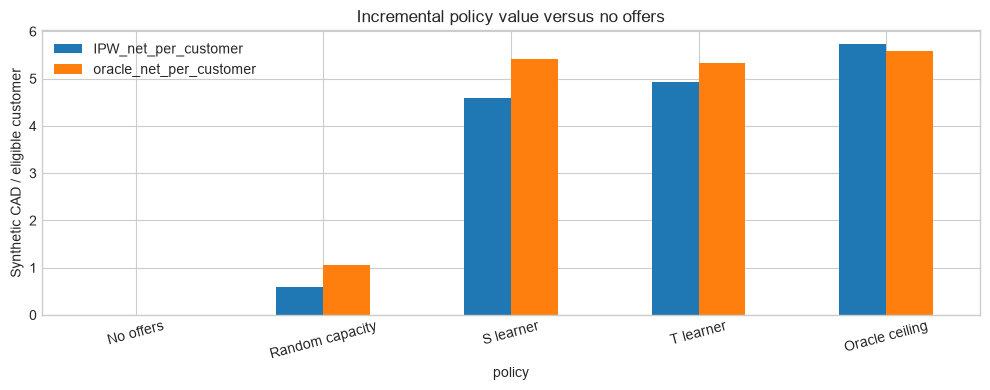

In [8]:
ur=np.random.default_rng(SEED+3); U=ur.normal(size=(9000,4)); T=ur.binomial(1,.5,len(U))
p0=expit(-1+.7*U[:,0]-.4*U[:,1])
p1=expit(-1+.7*U[:,0]-.4*U[:,1]+1.3*(U[:,2]>0)-.7*(U[:,2]<=0))
Y=ur.binomial(1,np.where(T==1,p1,p0)); truth=p1-p0
u_fit=np.arange(6000); u_test=np.arange(6000,9000)
def uplift_estimator(): return HistGradientBoostingClassifier(max_iter=90,max_leaf_nodes=8,l2_regularization=5,random_state=SEED)
s= uplift_estimator().fit(np.column_stack([U[u_fit],T[u_fit]]),Y[u_fit])
s_tau=s.predict_proba(np.column_stack([U[u_test],np.ones(len(u_test))]))[:,1]-s.predict_proba(np.column_stack([U[u_test],np.zeros(len(u_test))]))[:,1]
tm={a:uplift_estimator().fit(U[u_fit][T[u_fit]==a],Y[u_fit][T[u_fit]==a]) for a in [0,1]}
t_tau=tm[1].predict_proba(U[u_test])[:,1]-tm[0].predict_proba(U[u_test])[:,1]
def allocate(tau):
    chosen=np.argsort(-tau,kind='stable')[:int(.2*len(tau))]
    policy=np.zeros(len(tau)); policy[chosen]=100*tau[chosen]>3
    return policy
policies={'No offers':np.zeros(len(u_test)),
 'Random capacity':allocate(ur.uniform(.04,.3,len(u_test))),
 'S learner':allocate(s_tau),'T learner':allocate(t_tau),
 'Oracle ceiling':allocate(truth[u_test])}
pseudo=Y[u_test]*(T[u_test]/.5-(1-T[u_test])/.5)
oracle_value=np.mean(policies['Oracle ceiling']*(100*truth[u_test]-3))
policy_rows=[]
for name,policy in policies.items():
    contributions=policy*(100*pseudo-3)
    vals=[contributions[ur.integers(0,len(u_test),len(u_test))].mean() for _ in range(300)]
    expected=np.mean(policy*(100*truth[u_test]-3))
    policy_rows.append({'policy':name,'contact_rate':policy.mean(),'IPW_net_per_customer':contributions.mean(),
        'CI_low':np.quantile(vals,.025),'CI_high':np.quantile(vals,.975),
        'oracle_net_per_customer':expected,'oracle_regret':oracle_value-expected})
policy_table=pd.DataFrame(policy_rows); display(policy_table)
policy_table.plot.bar(x='policy',y=['IPW_net_per_customer','oracle_net_per_customer'],figsize=(10,4),rot=15)
plt.ylabel('Synthetic CAD / eligible customer'); plt.title('Incremental policy value versus no offers'); plt.tight_layout(); plt.show()

## 8. Stress-test a frozen deployed model with actual scored cohorts

Unlike illustrative monitoring curves, each scenario below generates fresh features and labels and runs the frozen classifier. Traffic shift changes the sessions distribution; missingness simulates an instrumentation failure; concept shift changes response conditional on channel while leaving input distributions largely unchanged. KS is descriptive and misses multivariate and categorical drift. The missingness gap is a separate quality check. Alerts use illustrative fixed thresholds, not calibrated production false-alarm rates. Label-based metrics would arrive only after the 90-day outcome window.

,scenario,prevalence,sessions_KS,intent_missingness_gap,AP,Brier,input_alert,delayed_AP_alert
0,stable,0.154,0.032,-0.006,0.383,0.116,False,False
1,traffic,0.296,0.485,-0.005,0.600,0.168,True,False
2,missing,0.154,0.032,0.303,0.348,0.119,True,False
3,concept,0.179,0.032,-0.006,0.328,0.138,False,True


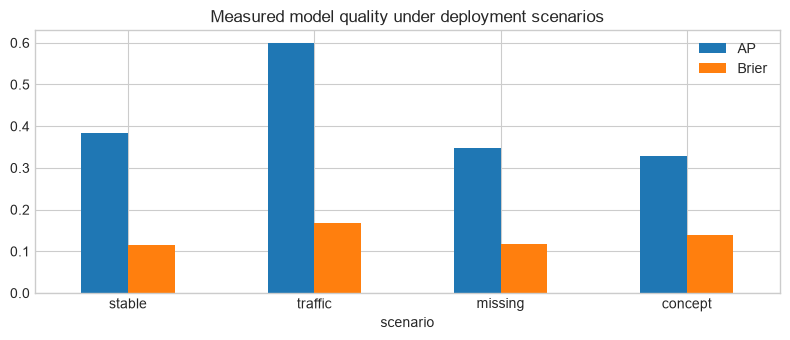

AP depends on prevalence; compare Brier, slices, and data changes before attributing degradation.


In [9]:
monitor_rows=[]
reference_ap=average_precision_score(y[test],prob)
for scenario in ['stable','traffic','missing','concept']:
    sx,sy,_,_=simulate(2500,SEED+4,scenario)
    sp=score(sx)
    ks=ks_2samp(X.iloc[fit].sessions,sx.sessions).statistic
    missing_gap=sx.intent.isna().mean()-X.iloc[fit].intent.isna().mean()
    ap=average_precision_score(sy,sp)
    monitor_rows.append({'scenario':scenario,'prevalence':sy.mean(),'sessions_KS':ks,
        'intent_missingness_gap':missing_gap,'AP':ap,'Brier':brier_score_loss(sy,sp),
        'input_alert':bool(ks>.15 or missing_gap>.1),'delayed_AP_alert':bool(ap<.8*reference_ap)})
monitor=pd.DataFrame(monitor_rows); display(monitor)
monitor.plot.bar(x='scenario',y=['AP','Brier'],figsize=(8,3.5),rot=0)
plt.title('Measured model quality under deployment scenarios'); plt.tight_layout(); plt.show()
print('AP depends on prevalence; compare Brier, slices, and data changes before attributing degradation.')

## 9. Package, reload, and test the inference contract

The bundle preserves both preprocessing and the separate calibration map. A reload parity assertion tests the exact predictions that deployment will serve. Schema validation rejects missing or extra columns and negative activity. Unknown channels are safely encoded rather than crashing, but should trigger monitoring. Joblib files must only be loaded from trusted sources; use matching dependency versions.

The model card records limitations and a rollout plan. A test-set diagnostic is not approval to deploy; launch requires prospective validation, representative data, data-owner review, and randomized measurement of downstream value.

In [10]:
def validate_frame(frame):
    if set(frame.columns)!=set(FEATURES): raise ValueError('Feature schema mismatch')
    if frame.sessions.isna().any() or (frame.sessions<0).any(): raise ValueError('Invalid sessions')
    for col in NUM:
        if not pd.api.types.is_numeric_dtype(frame[col]): raise ValueError('Non-numeric '+col)
    return frame[FEATURES]
bundle={'pipeline':champion,'calibrator':calibrator,'features':FEATURES,'capacity_fraction':.15}
artifact=OUT/'conversion_bundle.joblib'; joblib.dump(bundle,artifact)
loaded=joblib.load(artifact)
sample=validate_frame(X.iloc[test[:25]].copy())
reloaded=loaded['calibrator'].predict_proba(logit_scores(loaded['pipeline'].predict_proba(sample)[:,1]))[:,1]
assert np.allclose(reloaded,score(sample))
bad=sample.drop(columns='sessions')
try: validate_frame(bad)
except ValueError: pass
else: raise AssertionError('Missing feature was accepted')
unknown=sample.copy(); unknown['channel']='New partner'
assert np.isfinite(score(validate_frame(unknown))).all()
card={'synthetic_only':True,'seed':SEED,'versions':versions,'champion':winner,
 'fit_rows':len(fit),'calibration_rows':len(cal),'test_rows':len(test),
 'features':FEATURES,'label_horizon_days':90,'capacity_fraction':.15,
 'artifact_sha256':hashlib.sha256(artifact.read_bytes()).hexdigest(),
 'limitations':['Independent simulated cohorts; not evidence of real-world generalization',
 'Churn/conversion risk is not causal uplift','Marginal intervals need exchangeability',
 'No protected-group fairness certification','No automatic retraining on drift alone'],
 'rollout':['Shadow-score and validate schema','Audit mature labels and calibration',
 'Randomize intervention with a holdout','Rollback on verified quality or system failure']}
(OUT/'model_card.json').write_text(json.dumps(card,indent=2),encoding='utf-8')
for name,table in {'classifier_selection':leaderboard,'final_metrics':final_metrics,'regressor_selection':reg_table,
    'forecast_backtests':forecast_table,'uplift_policy':policy_table,'monitoring':monitor}.items():
    table.to_csv(OUT/(name+'.csv'),index=False)
display(pd.DataFrame([{'file':p.name,'bytes':p.stat().st_size} for p in sorted(OUT.iterdir())]))
print('PASS: disjoint partitions, schema rejection, unseen-category scoring, and reload parity.')

,file,bytes
0,classifier_selection.csv,588
1,conversion_bundle.joblib,4728
2,final_metrics.csv,304
3,forecast_backtests.csv,543
4,model_card.json,1049
5,monitoring.csv,526
6,regressor_selection.csv,148
7,uplift_policy.csv,514


PASS: disjoint partitions, schema rejection, unseen-category scoring, and reload parity.


## 10. What the case study establishes—and what it does not

The printed tables are the conclusions: the winning classifier is selected by selection AP; the value model by selection MAE; forecasting models are compared across three forward folds; uplift policies include sampling intervals and a simulation-only oracle ceiling. A more complex model is not guaranteed to win. Do not report selection scores as final test scores or interpret noisy policy estimates as assured profit.

Before extending this study: freeze another holdout, then add repeated cohort simulations, temporal label delays, grouped customers, broader hyperparameter search, quantile-adaptive conformal intervals, categorical drift, and prospective treatment experiments. Keep any new decisions off the existing test set.

### Method references
- [Scikit-learn: common pitfalls and leakage](https://scikit-learn.org/stable/common_pitfalls.html)
- [Probability calibration](https://scikit-learn.org/stable/modules/calibration.html)
- [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)
- [Angelopoulos & Bates: conformal prediction introduction](https://arxiv.org/abs/2107.07511)
- [Künzel et al.: meta-learners for heterogeneous treatment effects](https://www.pnas.org/doi/10.1073/pnas.1804597116)